In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements the AND logic using an MCP neuron.
    Returns 1 if the sum of inputs is >= T, else 0.
    """
    sum_inputs = X1 + X2
    return 1 if sum_inputs >= T else 0

def MCP_Neurons_OR(X1, X2, T):
    """
    Implements the OR logic using an MCP neuron.
    Returns 1 if the sum of inputs is >= T, else 0.
    """
    sum_inputs = X1 + X2
    return 1 if sum_inputs >= T else 0

print("MCP_Neurons_AND and MCP_Neurons_OR functions defined.")

MCP_Neurons_AND and MCP_Neurons_OR functions defined.


In [ ]:
inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]

# --- MCP_Neurons_AND Implementation ---
print("\n--- MCP Neuron for AND Gate ---")
T_AND = 2 # Threshold for AND gate
for X1, X2 in inputs:
    output = MCP_Neurons_AND(X1, X2, T_AND)
    print(f"Inputs: ({X1}, {X2}), Threshold: {T_AND}, Output: {output}")

# --- MCP_Neurons_OR Implementation ---
print("\n--- MCP Neuron for OR Gate ---")
T_OR = 1 # Threshold for OR gate
for X1, X2 in inputs:
    output = MCP_Neurons_OR(X1, X2, T_OR)
    print(f"Inputs: ({X1}, {X2}), Threshold: {T_OR}, Output: {output}")



--- MCP Neuron for AND Gate ---
Inputs: (0, 0), Threshold: 2, Output: 0
Inputs: (0, 1), Threshold: 2, Output: 0
Inputs: (1, 0), Threshold: 2, Output: 0
Inputs: (1, 1), Threshold: 2, Output: 1

--- MCP Neuron for OR Gate ---
Inputs: (0, 0), Threshold: 1, Output: 0
Inputs: (0, 1), Threshold: 1, Output: 1
Inputs: (1, 0), Threshold: 1, Output: 1
Inputs: (1, 1), Threshold: 1, Output: 1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df_0_1 = pd.read_csv('/content/sample_data/mnist_train_small.csv')

# Separate features (X) and labels (y)
# In MNIST datasets, the first column is typically the label, and the rest are features.
y = df_0_1.iloc[:, 0]    # The first column for labels
X = df_0_1.iloc[:, 1:]   # All columns from the second one onwards for features

print("Dataset 'mnist_train_small.csv' loaded.")
print(f"Shape of features (X): {X.shape}")
print(f"Shape of labels (y): {y.shape}")

Dataset 'mnist_train_small.csv' loaded.
Shape of features (X): (19999, 784)
Shape of labels (y): (19999,)


Shape of X_0s (filtered for label 0): (1962, 784)
Shape of X_1s (filtered for label 1): (2243, 784)
Number of 0s images to plot: 5
Number of 1s images to plot: 5


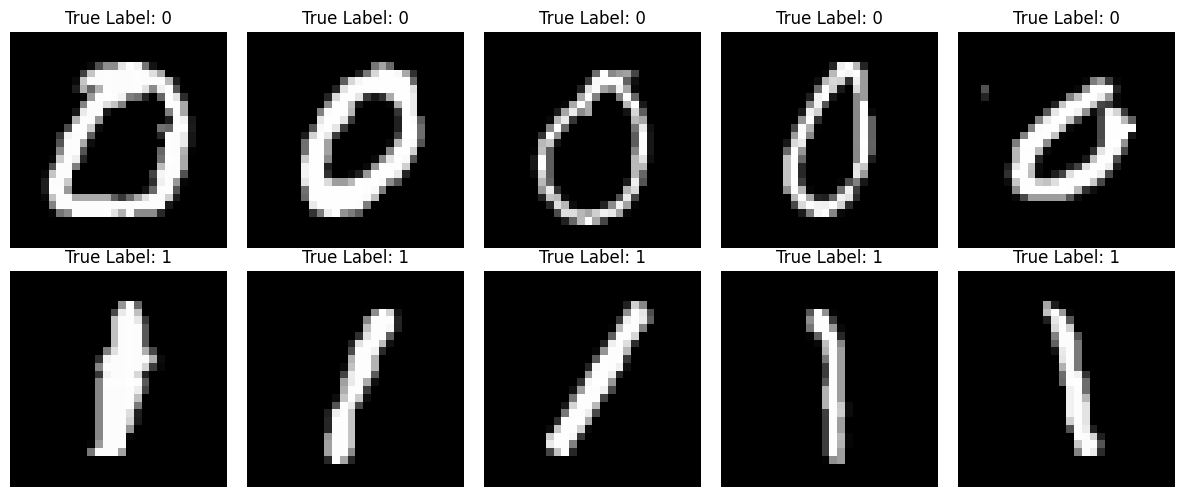

Attempted to display first 5 images of '0's and '1's.


In [ ]:
import matplotlib.pyplot as plt

# 1. Filter X and y to create separate DataFrames for images labeled as '0' and '1'.
X_0s = X[y == 0]
X_1s = X[y == 1]

print(f"Shape of X_0s (filtered for label 0): {X_0s.shape}")
print(f"Shape of X_1s (filtered for label 1): {X_1s.shape}")

# 2. Select the first 5 images from X_0s and the first 5 from X_1s.
# Using .values to convert DataFrame to numpy array for easier reshaping.
images_0s = X_0s.head(5).values
images_1s = X_1s.head(5).values

print(f"Number of 0s images to plot: {len(images_0s)}")
print(f"Number of 1s images to plot: {len(images_1s)}")

# Calculate image size (assuming square images)
image_size = int(np.sqrt(X.shape[1])) # Should be 28 for 784 features

# 4. Use matplotlib.pyplot to create a figure with subplots
plt.figure(figsize=(12, 5)) # Adjust figure size for better visibility

# Plot the first 5 '0's
for i in range(5):
    if i < len(images_0s):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images_0s[i].reshape(image_size, image_size), cmap='gray') # 5. Set colormap to 'gray'
        plt.title(f"True Label: 0") # 6. Add title
        plt.axis('off') # 7. Remove x and y axis ticks

# Plot the first 5 '1's
for i in range(5):
    if i < len(images_1s):
        plt.subplot(2, 5, i + 6) # Continue to the second row (i + 5 is 6, 7, 8, 9, 10)
        plt.imshow(images_1s[i].reshape(image_size, image_size), cmap='gray') # 5. Set colormap to 'gray'
        plt.title(f"True Label: 1") # 6. Add title
        plt.axis('off') # 7. Remove x and y axis ticks

plt.tight_layout() # 8. Adjust layout to prevent titles from overlapping
plt.show() # 9. Display the plots

print("Attempted to display first 5 images of '0's and '1's.")


In [ ]:
import numpy as np

# 1. Initialize weights to zeros, matching the number of features in X
# X.shape[1] gives the number of features
weights = np.zeros(X.shape[1])

# 2. Initialize bias to 0
bias = 0

# 3. Initialize learning rate to 0.1
learning_rate = 0.1

# 4. Initialize epochs to 100
epochs = 100

print(f"Weights initialized with shape: {weights.shape}")
print(f"Bias initialized to: {bias}")
print(f"Learning rate set to: {learning_rate}")
print(f"Epochs set to: {epochs}")

Weights initialized with shape: (784,)
Bias initialized to: 0
Learning rate set to: 0.1
Epochs set to: 100


In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Computes predictions using the dot product of X and weights, adds bias,
    and applies a step function.

    Args:
        X (numpy.ndarray): Feature matrix, where each row is a sample.
        weights (numpy.ndarray): Weight vector.
        bias (float): Bias term.

    Returns:
        numpy.ndarray: Array of predictions (0 or 1).
    """
    # Ensure X is treated as a 2D array if it's a single sample (1D array)
    if X.ndim == 1:
        X = X.reshape(1, -1)

    linear_output = np.dot(X, weights) + bias
    # Apply the step function: 1 if linear_output >= 0, else 0
    predictions = (linear_output >= 0).astype(int)
    return predictions

print("decision_function defined.")

decision_function defined.


In [ ]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate, epochs):
    """
    Implements the Perceptron learning algorithm to train the model.

    Args:
        X (pd.DataFrame): Feature matrix where each row is a sample.
        y (pd.Series): True labels for the samples.
        weights (np.ndarray): Initial weight vector.
        bias (float): Initial bias term.
        learning_rate (float): The learning rate for weight and bias updates.
        epochs (int): The number of training epochs.

    Returns:
        tuple: A tuple containing the final updated (weights, bias).
    """
    # Convert X and y to numpy arrays for efficient iteration and calculation
    X_np = X.values
    y_np = y.values

    for epoch in range(epochs):
        # Keep track of changes within the epoch
        epoch_changes = 0
        for i in range(X_np.shape[0]):
            current_X_sample = X_np[i]
            true_label = y_np[i]

            # Step 4: Call decision_function to get the prediction
            # The decision_function is designed to handle both single samples (1D) and multiple samples (2D)
            prediction = decision_function(current_X_sample, weights, bias)[0] # [0] to get the scalar prediction

            # Step 5: Update weights and bias if misclassification occurs
            if prediction != true_label:
                error = true_label - prediction
                weights = weights + learning_rate * error * current_X_sample
                bias = bias + learning_rate * error
                epoch_changes += 1

        # Step 6: After each epoch, calculate and print the training accuracy
        # Make predictions for all samples using the updated weights and bias
        all_predictions = decision_function(X_np, weights, bias)

        # Convert y_np to int type for consistent comparison if needed (though usually not necessary with 0/1)
        accuracy = np.mean(all_predictions == y_np.astype(int))
        print(f"Epoch {epoch + 1}: Accuracy = {accuracy:.4f} (Changes in epoch: {epoch_changes})")

    print("\nPerceptron training complete.")
    # Step 7: Return the final updated weights and bias
    return weights, bias

print("train_perceptron function defined.")

train_perceptron function defined.


In [ ]:
import numpy as np
import pandas as pd

# 1. Filter X and y for labels 0 and 1
# Assuming y is a pandas Series and X is a pandas DataFrame
mask_0_1 = (y == 0) | (y == 1)
X_0_1 = X[mask_0_1]
y_0_1 = y[mask_0_1]

print(f"Shape of X_0_1 (filtered for labels 0 and 1): {X_0_1.shape}")
print(f"Shape of y_0_1 (filtered for labels 0 and 1): {y_0_1.shape}")

Shape of X_0_1 (filtered for labels 0 and 1): (4205, 784)
Shape of y_0_1 (filtered for labels 0 and 1): (4205,)


In [ ]:
import numpy as np

# 2. Re-initialize weights for the 0 vs 1 classification
# The number of features remains the same as original X, but we are training on X_0_1
# It's important to re-initialize if the context implies starting fresh for this specific task.
weights_0_1 = np.zeros(X_0_1.shape[1])

# Bias, learning_rate, and epochs are already defined from previous steps
# bias = bias # (0 from previous cell)
# learning_rate = learning_rate # (0.1 from previous cell)
# epochs = epochs # (100 from previous cell)

print(f"Re-initialized weights_0_1 with shape: {weights_0_1.shape}")

# 3. Call the train_perceptron function
print("\nStarting Perceptron training for 0 vs 1 classification...")
final_weights_0_1, final_bias_0_1 = train_perceptron(X_0_1, y_0_1, weights_0_1, bias, learning_rate, epochs)

# 5. Calculate the final accuracy on the X_0_1 and y_0_1 datasets
final_predictions_0_1 = decision_function(X_0_1, final_weights_0_1, final_bias_0_1)
final_accuracy_0_1 = np.mean(final_predictions_0_1 == y_0_1.values.astype(int))

# 6. Print the final accuracy
print(f"\nFinal Accuracy on 0 vs 1 dataset: {final_accuracy_0_1:.4f}")

Re-initialized weights_0_1 with shape: (784,)

Starting Perceptron training for 0 vs 1 classification...
Epoch 1: Accuracy = 0.9960 (Changes in epoch: 29)
Epoch 2: Accuracy = 0.9971 (Changes in epoch: 11)
Epoch 3: Accuracy = 0.9995 (Changes in epoch: 5)
Epoch 4: Accuracy = 0.9995 (Changes in epoch: 4)
Epoch 5: Accuracy = 0.9988 (Changes in epoch: 3)
Epoch 6: Accuracy = 0.9993 (Changes in epoch: 2)
Epoch 7: Accuracy = 0.9988 (Changes in epoch: 2)
Epoch 8: Accuracy = 1.0000 (Changes in epoch: 2)
Epoch 9: Accuracy = 1.0000 (Changes in epoch: 0)
Epoch 10: Accuracy = 1.0000 (Changes in epoch: 0)
Epoch 11: Accuracy = 1.0000 (Changes in epoch: 0)
Epoch 12: Accuracy = 1.0000 (Changes in epoch: 0)
Epoch 13: Accuracy = 1.0000 (Changes in epoch: 0)
Epoch 14: Accuracy = 1.0000 (Changes in epoch: 0)
Epoch 15: Accuracy = 1.0000 (Changes in epoch: 0)
Epoch 16: Accuracy = 1.0000 (Changes in epoch: 0)
Epoch 17: Accuracy = 1.0000 (Changes in epoch: 0)
Epoch 18: Accuracy = 1.0000 (Changes in epoch: 0)
Ep

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Use the decision_function with X_0_1, final_weights_0_1, and final_bias_0_1 to get predictions
predictions_0_1_all = decision_function(X_0_1, final_weights_0_1, final_bias_0_1)

# 2. Identify the indices where predictions_0_1_all do not match y_0_1.values
misclassified_idx = np.where(predictions_0_1_all != y_0_1.values)[0]

# 3. Check if misclassified_idx is empty
if len(misclassified_idx) == 0:
    print('No misclassified images found for 0 vs 1 classification. The model achieved 100% accuracy.')
else:
    print(f"Found {len(misclassified_idx)} misclassified images.")
    # 4. If misclassified_idx is not empty, select up to 10 of these indices to visualize.
    images_to_plot = misclassified_idx[:10]

    # Calculate image size (assuming square images)
    image_size = int(np.sqrt(X_0_1.shape[1])) # Should be 28 for 784 features

    # 5. Create a figure with subplots to display these misclassified images.
    plt.figure(figsize=(15, 6))

    for i, idx in enumerate(images_to_plot):
        plt.subplot(2, 5, i + 1)
        # a. Reshape the image data from X_0_1
        image_data = X_0_1.iloc[idx].values.reshape(image_size, image_size)
        # b. Use plt.imshow to display the image in grayscale
        plt.imshow(image_data, cmap='gray')
        # c. Set the title of each subplot to show both the 'True Label' and the 'Predicted Label'
        true_label = y_0_1.iloc[idx]
        predicted_label = predictions_0_1_all[idx]
        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        # d. Turn off the axes
        plt.axis('off')

    # 6. Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()


No misclassified images found for 0 vs 1 classification. The model achieved 100% accuracy.


In [ ]:
import numpy as np
import pandas as pd

# 1. (Reusing already loaded X and y from 'mnist_train_small.csv')
# The dataset 'mnist_train_small.csv' was already loaded in a previous step
# as 'df_0_1', and 'X' and 'y' were extracted. We will continue using these.

# 2. Filter X and y for labels 3 and 5
mask_3_5 = (y == 3) | (y == 5)
X_3_5 = X[mask_3_5]
y_3_5 = y[mask_3_5]

print(f"Shape of X_3_5 (filtered for labels 3 and 5): {X_3_5.shape}")
print(f"Shape of y_3_5 (filtered for labels 3 and 5): {y_3_5.shape}")

# It's important to replace 3 with 0 and 5 with 1 for binary classification
# The perceptron is trained to distinguish between 0 and 1.
# Let's map 3 to 0 and 5 to 1 for the perceptron.
y_3_5_mapped = y_3_5.replace({3: 0, 5: 1})
print("Labels 3 and 5 mapped to 0 and 1 respectively for training.")

# 3. Re-initialize weights for the 3 vs 5 classification
weights_3_5 = np.zeros(X_3_5.shape[1])

# 4. Use the existing bias, learning_rate, and epochs variables
# bias, learning_rate, and epochs are already defined from previous steps
# (e.g., bias = 0, learning_rate = 0.1, epochs = 100)

print(f"Re-initialized weights_3_5 with shape: {weights_3_5.shape}")

# 5. Call the train_perceptron function
print("\nStarting Perceptron training for 3 vs 5 classification...")
final_weights_3_5, final_bias_3_5 = train_perceptron(X_3_5, y_3_5_mapped, weights_3_5, bias, learning_rate, epochs)

# 6. Calculate the final predictions on the X_3_5 dataset
final_predictions_3_5 = decision_function(X_3_5, final_weights_3_5, final_bias_3_5)

# 7. Compute the final accuracy for the 3 vs 5 classification
final_accuracy_3_5 = np.mean(final_predictions_3_5 == y_3_5_mapped.values.astype(int))

# 8. Print the final accuracy
print(f"\nFinal Accuracy on 3 vs 5 dataset: {final_accuracy_3_5:.4f}")

Shape of X_3_5 (filtered for labels 3 and 5): (3782, 784)
Shape of y_3_5 (filtered for labels 3 and 5): (3782,)
Labels 3 and 5 mapped to 0 and 1 respectively for training.
Re-initialized weights_3_5 with shape: (784,)

Starting Perceptron training for 3 vs 5 classification...
Epoch 1: Accuracy = 0.9408 (Changes in epoch: 400)
Epoch 2: Accuracy = 0.9476 (Changes in epoch: 296)
Epoch 3: Accuracy = 0.9553 (Changes in epoch: 265)
Epoch 4: Accuracy = 0.9395 (Changes in epoch: 245)
Epoch 5: Accuracy = 0.9204 (Changes in epoch: 260)
Epoch 6: Accuracy = 0.9498 (Changes in epoch: 253)
Epoch 7: Accuracy = 0.9532 (Changes in epoch: 215)
Epoch 8: Accuracy = 0.9564 (Changes in epoch: 212)
Epoch 9: Accuracy = 0.9490 (Changes in epoch: 219)
Epoch 10: Accuracy = 0.9609 (Changes in epoch: 226)
Epoch 11: Accuracy = 0.9622 (Changes in epoch: 209)
Epoch 12: Accuracy = 0.9577 (Changes in epoch: 199)
Epoch 13: Accuracy = 0.9537 (Changes in epoch: 201)
Epoch 14: Accuracy = 0.9622 (Changes in epoch: 197)
Epoc

**Reasoning**:
I need to visualize the misclassified images for the 3 vs 5 classification. I will use the `decision_function` to get predictions, compare them with the true labels (`y_3_5_mapped`), identify misclassified indices, and then plot up to 10 of these images with their true and predicted labels.



Found 91 misclassified images.


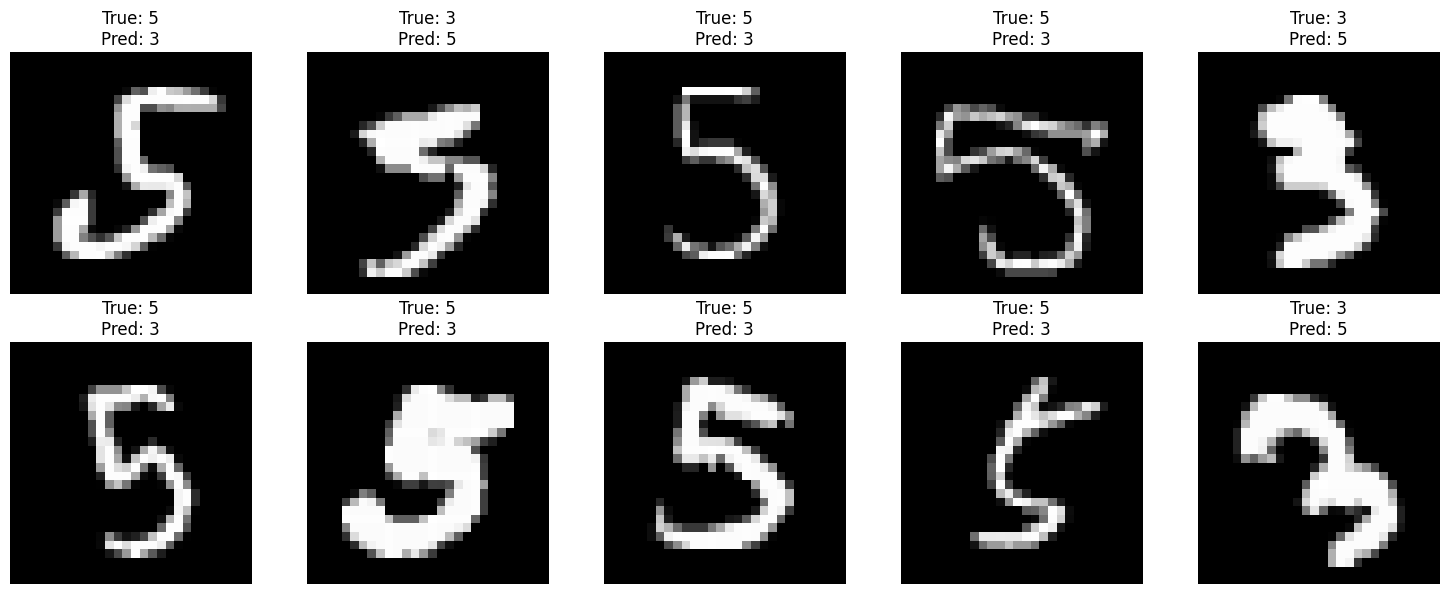

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Use the decision_function with X_3_5, final_weights_3_5, and final_bias_3_5 to get predictions
predictions_3_5_all = decision_function(X_3_5, final_weights_3_5, final_bias_3_5)

# 2. Identify the indices where predictions_3_5_all do not match y_3_5_mapped.values
misclassified_idx_3_5 = np.where(predictions_3_5_all != y_3_5_mapped.values)[0]

# 3. Check if misclassified_idx_3_5 is empty
if len(misclassified_idx_3_5) == 0:
    print('No misclassified images found for 3 vs 5 classification. The model achieved 100% accuracy.')
else:
    print(f"Found {len(misclassified_idx_3_5)} misclassified images.")
    # 4. If misclassified_idx_3_5 is not empty, select up to 10 of these indices to visualize.
    images_to_plot_3_5 = misclassified_idx_3_5[:10]

    # Calculate image size (assuming square images)
    image_size = int(np.sqrt(X_3_5.shape[1])) # Should be 28 for 784 features

    # 5. Create a figure with subplots to display these misclassified images.
    plt.figure(figsize=(15, 6))

    for i, idx in enumerate(images_to_plot_3_5):
        plt.subplot(2, 5, i + 1)
        # a. Reshape the image data from X_3_5
        image_data = X_3_5.iloc[idx].values.reshape(image_size, image_size)
        # b. Use plt.imshow to display the image in grayscale
        plt.imshow(image_data, cmap='gray')
        # c. Set the title of each subplot to show both the 'True Label' and the 'Predicted Label'
        true_label = y_3_5_mapped.iloc[idx]
        # Map back to original labels for display
        true_display_label = 3 if true_label == 0 else 5
        predicted_label = predictions_3_5_all[idx]
        predicted_display_label = 3 if predicted_label == 0 else 5
        plt.title(f"True: {true_display_label}\nPred: {predicted_display_label}")
        # d. Turn off the axes
        plt.axis('off')

    # 6. Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()